In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path


sys.path.append("..")
from src.utils import load_config
config = load_config()
data_path = Path("..") / config['paths']['extract_dir']
answers_path = Path("..") / config['paths']['raw_dir'] / "answers"
print(f"Loading data from: {data_path}")
print(f"Answers from: {answers_path}")

In [8]:
def load_cert_file(filename):
    return pd.read_csv(data_path / filename, parse_dates=['date'])

# Load core activity files
logon = load_cert_file("logon.csv")
device = load_cert_file("device.csv")
http = load_cert_file("http.csv") #very large



--- Logon Info ---
Shape: (1810070, 5)
                         id                date     user       pc activity
0  {Q4D5-W4HH44UC-5188LWZK} 2010-01-02 02:24:51  JBI1134  PC-0168    Logon
1  {G7V0-S4TP95SA-9203AOGR} 2010-01-02 02:38:28  JBI1134  PC-0168   Logoff
2  {B4U7-K4DB84LM-2657VBFY} 2010-01-02 04:55:52  JBI1134  PC-2320    Logon
Unique Users: 2000

--- Device Info ---
Shape: (836984, 6)
                         id                date     user       pc  \
0  {C9S1-Y8GB42VD-2923GATU} 2010-01-02 07:27:19  HRE1950  PC-8025   
1  {C3G4-U2ON02HC-9088IHGJ} 2010-01-02 07:40:51  EMR0269  PC-6370   
2  {X4S2-R2YC60OH-9191YYMD} 2010-01-02 07:45:00  EMR0269  PC-6370   

                                         file_tree    activity  
0             R:\;R:\HRE1950;R:\47yHBn0;R:\54s7J45     Connect  
1  R:\;R:\EMR0269;R:\753Cf59;R:\18d36D6;R:\89bc6Q2     Connect  
2                                              NaN  Disconnect  
Unique Users: 447


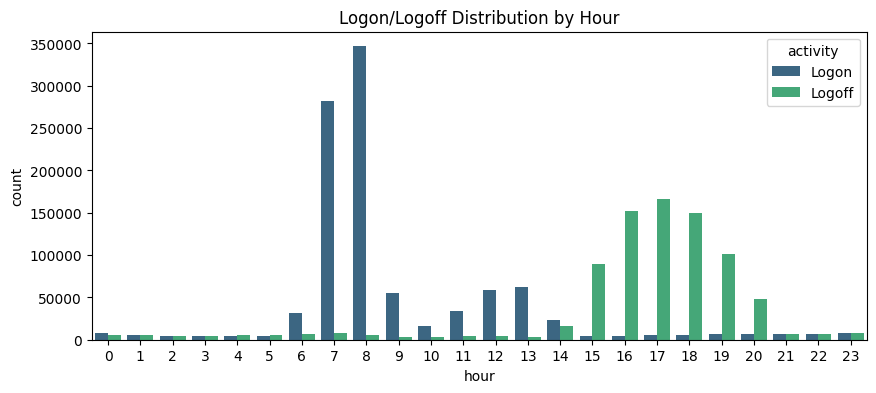

In [ ]:
for name, df in [("Logon", logon), ("Device", device)]:
    print(f"\n--- {name} Info ---")
    print(f"Shape: {df.shape}")
    print(df.head(3))
    print(f"Unique Users: {df['user'].nunique()}")

# temporal analysis: event distribution over hours of the day 
logon['hour'] = logon['date'].dt.hour
plt.figure(figsize=(10, 4))
sns.countplot(data=logon, x='hour', hue='activity', palette='viridis')
plt.title("Logon/Logoff Distribution by Hour")
plt.show()


In [22]:
#  how many unique PCs a user interacts with
user_pc_counts = logon.groupby('user')['pc'].nunique().sort_values(ascending=False)
print(f"\nAverage PCs per user: {user_pc_counts.mean():.2f}")
print(f"Max PCs accessed by one user: {user_pc_counts.max()}")


Average PCs per user: 32.80
Max PCs accessed by one user: 1032


In [ ]:
insiders = pd.read_csv(answers_path / "insiders.csv") 
print(f"Total insider records: {len(insiders)}")
print(f"Unique malicious users: {insiders['user'].nunique()}")

User counts:
is_malicious
False    1901
True       99
Name: count, dtype: int64


/var/folders/gs/9dn2ztbs4v5bvf7hdmm963nr0000gn/T/ipykernel_68066/1087889590.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_users, x='is_malicious', palette='viridis')


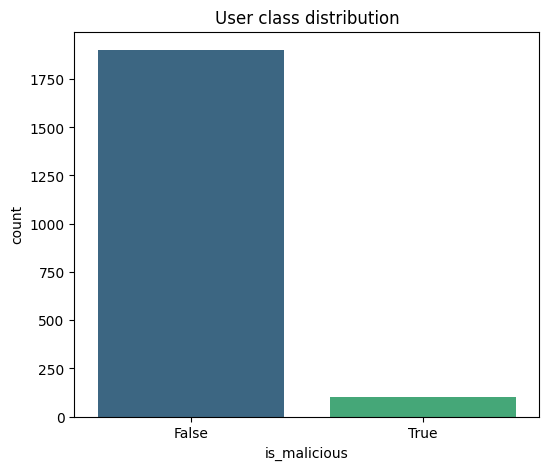

In [24]:

# Create user labels
malicious_users = set(insiders['user'].unique())
all_users = logon['user'].unique()

df_users = pd.DataFrame({'user': all_users})
df_users['is_malicious'] = df_users['user'].isin(malicious_users)

# Print summary statistics
print("User counts:")
print(df_users['is_malicious'].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df_users, x='is_malicious', palette='viridis')
plt.title("User class distribution")
plt.show()